In [89]:
import os
import pickle
import pandas as pd
import seaborn as sns
from autorank import autorank, plot_stats, create_report
import matplotlib.pyplot as plt

In [95]:
# Calculate mean ATE relative error for all methods and datasets
mean_ate_by_method_dataset = baseline_df.groupby(['model', 'dataset'])['ate_rel_err'].mean().reset_index()
mean_ate_by_method_dataset.columns = ['Model', 'Dataset', 'Mean ATE Rel Error']

# Pivot to show methods as rows and datasets as columns
pivot_table = mean_ate_by_method_dataset.pivot(index='Model', columns='Dataset', values='Mean ATE Rel Error')

print("Mean ATE Relative Error by Method and Dataset:")
print("=" * 80)
print(pivot_table.to_string())
print("\n" + "=" * 80)

# Also show overall mean by method (across all datasets)
print("\nOverall Mean ATE Relative Error by Method (across all datasets):")
print("=" * 80)
overall_mean = baseline_df.groupby('model')['ate_rel_err'].mean().sort_values()
print(overall_mean.to_string())

# Show overall mean by dataset (across all methods)
print("\n" + "=" * 80)
print("\nOverall Mean ATE Relative Error by Dataset (across all methods):")
print("=" * 80)
dataset_mean = baseline_df.groupby('dataset')['ate_rel_err'].mean().sort_values()
print(dataset_mean.to_string())

Mean ATE Relative Error by Method and Dataset:
Dataset               ACIC       CPS      IHDP      PSID
Model                                                   
causalfm          1.028785  0.999955  1.224143  0.999978
causalpfn         0.055058  0.142538  0.028511  0.222115
dopfn             0.664440  0.879620  0.932473  0.926963
s_learner_tabpfn  0.020727  0.515941  0.030983  0.506338
t_learner_tabpfn  0.013808  0.248124  0.027091  0.100824
x_learner_tabpfn  0.014573  0.631590  0.045352  0.691649


Overall Mean ATE Relative Error by Method (across all datasets):
model
t_learner_tabpfn    0.097462
causalpfn           0.112056
s_learner_tabpfn    0.268497
x_learner_tabpfn    0.345791
dopfn               0.850874
causalfm            1.063216


Overall Mean ATE Relative Error by Dataset (across all methods):
dataset
ACIC    0.299565
IHDP    0.381426
CPS     0.569628
PSID    0.574645


In [91]:
root_dir = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/RealCauseEval/results/tlearner_final"

eval_df = pd.DataFrame()

for root, dirs, files in os.walk(root_dir):
    for file in files:
        file_path = os.path.join(root, file)
        with open(file_path, 'rb') as f:
            try:
                data = pickle.load(f)
                data.pop("cate_preds")
                eval_df = pd.concat([pd.DataFrame([data]), eval_df])
            
            except (pickle.UnpicklingError, EOFError):
                print(f"Skipping corrupted file: {file}")

In [92]:
# 1. Extract just the baseline values into a lookup table
baseline_lookup = eval_df[eval_df['model'] == 't_learner_tabpfn'][['dataset', 'realization', 'pehe']]
baseline_lookup = baseline_lookup.rename(columns={'pehe': 'baseline_pehe'})

# 2. Merge the baseline values back into the main dataframee
eval_df = eval_df.merge(baseline_lookup, on=['dataset', 'realization'], how='left')

# 3. Calculate the normalized column
eval_df['normalized_pehe'] = eval_df['pehe'] / eval_df['baseline_pehe']

# 4. (Optional) Remove the helper column
eval_df = eval_df.drop(columns=['baseline_pehe'])

In [93]:
eval_df["ate_rel_err"] = eval_df["ate_rel_err"].astype(float)

In [94]:
eval_df.groupby("dataset")["ate_rel_err"].mean()

dataset
ACIC    0.210416
CPS     0.270671
IHDP    0.134544
PSID    0.085264
Name: ate_rel_err, dtype: float64

/Users/arikreuter/miniforge/envs/fastpy/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


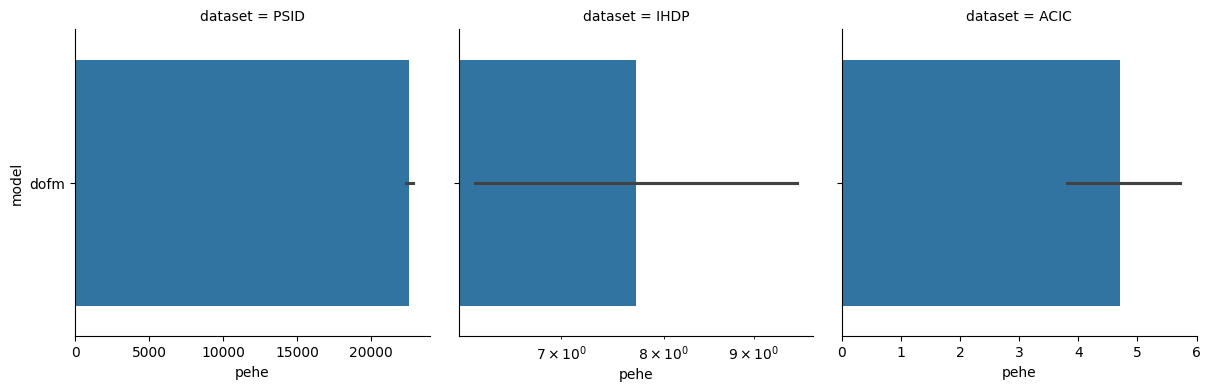

In [51]:
g = sns.FacetGrid(eval_df, col="dataset", col_wrap=4, height=4, sharex=False)

g.map(sns.barplot, "pehe", "model")

g.axes[1].set_xscale("log")
#g.axes[3].set_xscale("log")

In [52]:
g = sns.FacetGrid(eval_df, col="dataset", col_wrap=4, height=4, sharex=False)

g.map(sns.barplot, "normalized_pehe", "model")

g.axes[1].set_xscale("log")
g.axes[3].set_xscale("log")

/Users/arikreuter/miniforge/envs/fastpy/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


IndexError: index 3 is out of bounds for axis 0 with size 3

Error in callback <function _draw_all_if_interactive at 0x16a237560> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1600x400 with 3 Axes>

/Users/arikreuter/miniforge/envs/fastpy/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


IndexError: index 3 is out of bounds for axis 0 with size 3

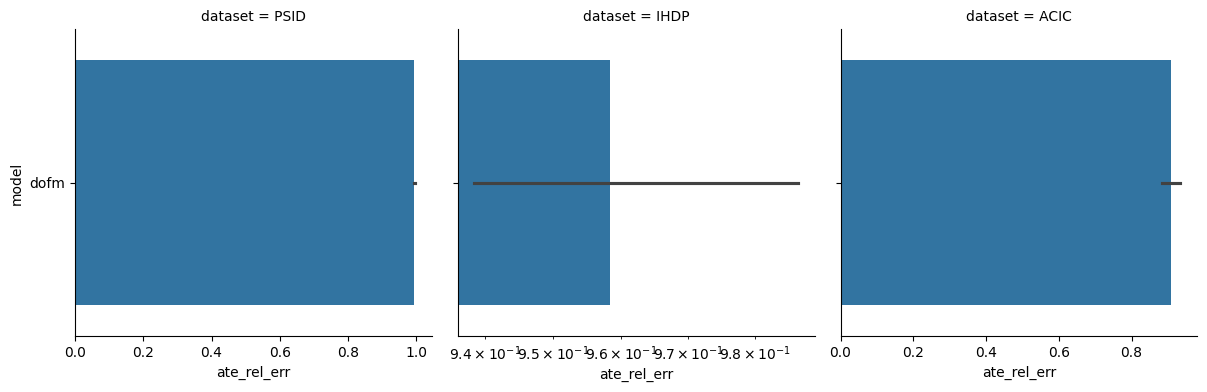

In [53]:
g = sns.FacetGrid(eval_df, col="dataset", col_wrap=4, height=4, sharex=False)

g.map(sns.barplot, "ate_rel_err", "model")

g.axes[1].set_xscale("log")
g.axes[3].set_xscale("log")

/Users/arikreuter/miniforge/envs/fastpy/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


IndexError: index 2 is out of bounds for axis 0 with size 2

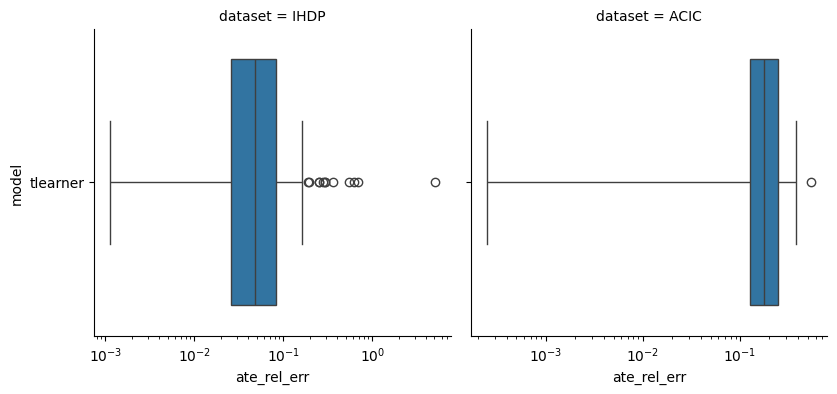

In [24]:
g = sns.FacetGrid(eval_df, col="dataset", col_wrap=4, height=4, sharex=False)

g.map(sns.boxplot, "ate_rel_err", "model")

g.axes[0].set_xscale("log")
g.axes[1].set_xscale("log")
g.axes[2].set_xscale("log")
g.axes[3].set_xscale("log")

The statistical analysis was conducted for 6 populations with 10 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We failed to reject the null hypothesis that the population is normal for all populations (minimal observed p-value=0.031). Therefore, we assume that all populations are normal.
We applied Bartlett's test for homogeneity and reject the null hypothesis (p=0.000) that thedata is homoscedastic. Thus, we assume that our data is heteroscedastic.
Because we have more than two populations and the populations are normal but heteroscedastic, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the mean values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the mean value (M), the standard deviation (SD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference

/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:432: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(sorted_ranks[i] - sorted_ranks[j]) <= critical_difference:
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:511: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_line([(rankpos(sorted_ranks[i]), cline),
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:512: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent w

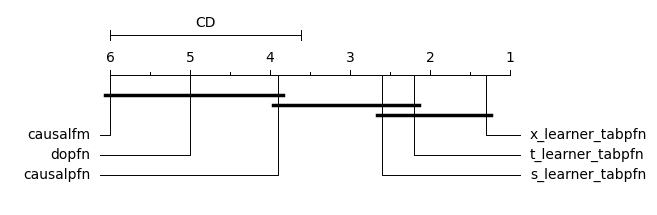

In [77]:

pivot_df = eval_df[eval_df["dataset"] == "ACIC"].pivot_table(
    index=['dataset', 'realization'], 
    columns='model', 
    values='pehe'
)

pivot_df = pivot_df.dropna()

result = autorank(pivot_df, alpha=0.05, verbose=False, order="ascending")

create_report(result)

plot_stats(result)
plt.show()

The statistical analysis was conducted for 6 populations with 27 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations causalpfn (p=0.002) and s_learner_tabpfn (p=0.001). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=1.451 of the Nemenyi test.
We reject the null hypothesis (p=0.000) of the Friedman t

/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:432: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(sorted_ranks[i] - sorted_ranks[j]) <= critical_difference:
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:511: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_line([(rankpos(sorted_ranks[i]), cline),
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:512: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent w

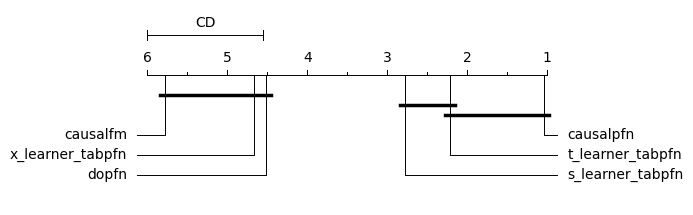

In [78]:

pivot_df = eval_df[eval_df["dataset"] == "CPS"].pivot_table(
    index=['dataset', 'realization'], 
    columns='model', 
    values='pehe'
)

pivot_df = pivot_df.dropna()

result = autorank(pivot_df, alpha=0.05, verbose=False, order="ascending")

create_report(result)

plot_stats(result)
plt.show()

The statistical analysis was conducted for 6 populations with 237 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations t_learner_tabpfn (p=0.000), causalpfn (p=0.000), s_learner_tabpfn (p=0.000), x_learner_tabpfn (p=0.000), dopfn (p=0.000), and causalfm (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical d

/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:432: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(sorted_ranks[i] - sorted_ranks[j]) <= critical_difference:
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:511: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_line([(rankpos(sorted_ranks[i]), cline),
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:512: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent w

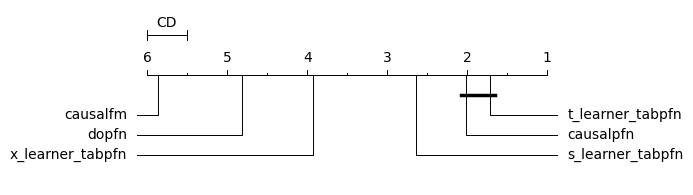

In [81]:

pivot_df = eval_df.pivot_table(
    index=['dataset', 'realization'], 
    columns='model', 
    values='pehe'
)

pivot_df = pivot_df.dropna()

result = autorank(pivot_df, alpha=0.05, verbose=False, order="ascending")

create_report(result)

plot_stats(result)
plt.show()

The statistical analysis was conducted for 6 populations with 100 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations t_learner_tabpfn (p=0.000), causalpfn (p=0.000), s_learner_tabpfn (p=0.000), and causalfm (p=0.002). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.754 of the Nemenyi test.
We reje

/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:432: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(sorted_ranks[i] - sorted_ranks[j]) <= critical_difference:
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:511: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_line([(rankpos(sorted_ranks[i]), cline),
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:512: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent w

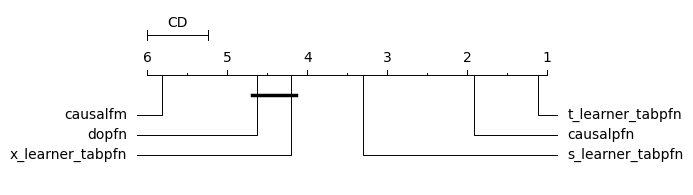

In [79]:

pivot_df = eval_df[eval_df["dataset"] == "PSID"].pivot_table(
    index=['dataset', 'realization'], 
    columns='model', 
    values='pehe'
)

pivot_df = pivot_df.dropna()

result = autorank(pivot_df, alpha=0.05, verbose=False, order="ascending")

create_report(result)

plot_stats(result)
plt.show()

The statistical analysis was conducted for 6 populations with 100 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations s_learner_tabpfn (p=0.000), t_learner_tabpfn (p=0.000), causalpfn (p=0.000), x_learner_tabpfn (p=0.000), dopfn (p=0.000), and causalfm (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical d

/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:432: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(sorted_ranks[i] - sorted_ranks[j]) <= critical_difference:
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:511: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_line([(rankpos(sorted_ranks[i]), cline),
/home/robertsj/miniconda3/envs/dofm/lib/python3.10/site-packages/autorank/_util.py:512: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent w

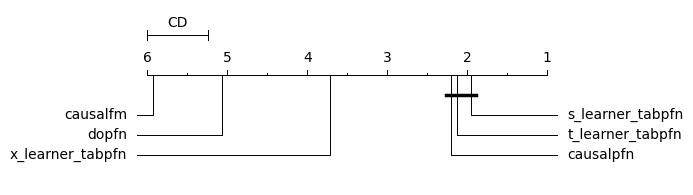

In [80]:

pivot_df = eval_df[eval_df["dataset"] == "IHDP"].pivot_table(
    index=['dataset', 'realization'], 
    columns='model', 
    values='pehe'
)

pivot_df = pivot_df.dropna()

result = autorank(pivot_df, alpha=0.05, verbose=False, order="ascending")

create_report(result)

plot_stats(result)
plt.show()